## Calving series statistics for Jakobshavn Isbrae ##

This notebook is the introduction to fitting statistical parameters to characterize the calving (length) time series for glacier Jakobshavn Isbrae in Greenland. 

A Poisson process models random events occurring in time (or space) where:
- Events occur independently
- The average rate of events is constant: 𝜆
- Number of events through time N(t)

Note that there is a difference between a Poisson process and a compound Poisson process. 



In [1]:
# Notebook set up: import dependencies and load in data
# Run this on greenlandMapping
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fractions
import scipy
from matplotlib.collections import LineCollection
import jump_process # dans .py 
from scipy.stats import poisson

### 1. Simulating a Poisson process ###

Objective is to _"write some code simulating a poisson process"_

Starting here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html

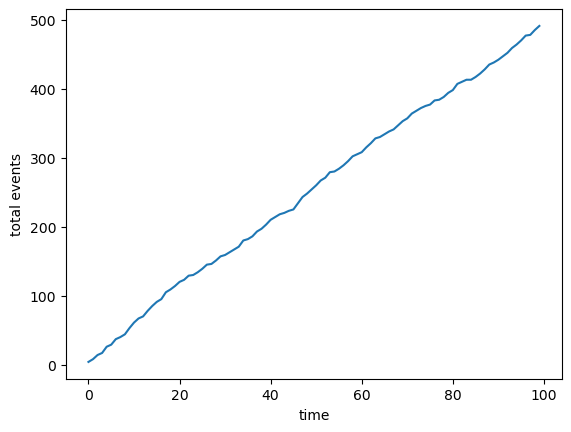

In [2]:
# rate 
lam = 5

# number of time intervals
T = 100

# simulate counts per interval
    #rvs(mu, loc=0, size=1, random_state=None)
events = poisson.rvs(mu=lam, size=T) # random variates 

# cumulative number of events
cumulative_events = np.cumsum(events)

plt.plot(cumulative_events)
plt.xlabel("time")
plt.ylabel("total events")
plt.show()

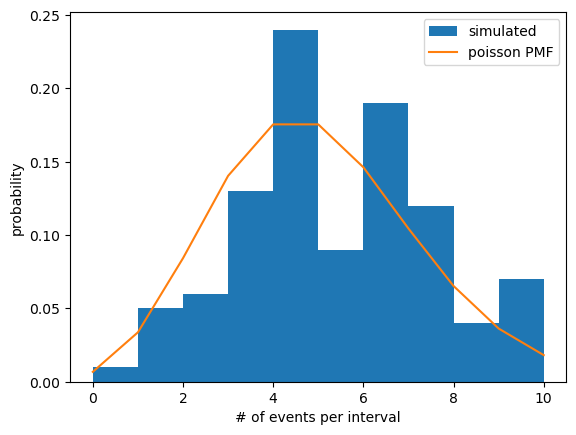

theoretical mean: 5.0
theoretical variance: 5.0
theoretical std: 2.23606797749979
theoretical median: 5.0


In [3]:
#looking at a probability mass function 
# possible event counts
k = np.arange(0, max(events)+1)

# theoretical PMF
pmf = poisson.pmf(k, mu=lam)

# histogram of simulated data
plt.hist(events, bins= 10, density=True, label="simulated")

# theoretical PMF
plt.plot(k, pmf, '-', label="poisson PMF")
plt.xlabel("# of events per interval")
plt.ylabel("probability")
plt.legend()
plt.show()

print("theoretical mean:", poisson.mean(mu=lam))
print("theoretical variance:", poisson.var(mu=lam))
print("theoretical std:", poisson.std(mu=lam))
print("theoretical median:", poisson.median(mu=lam))

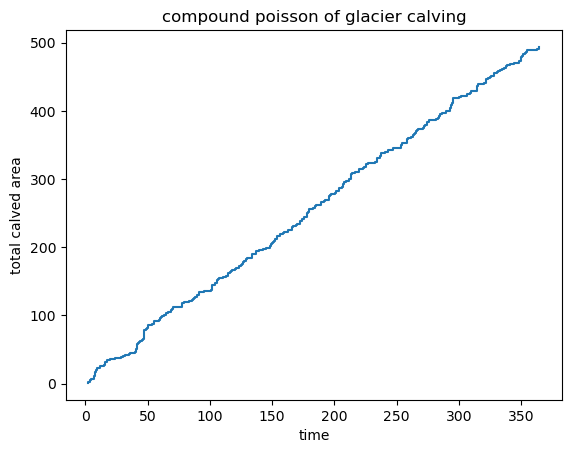

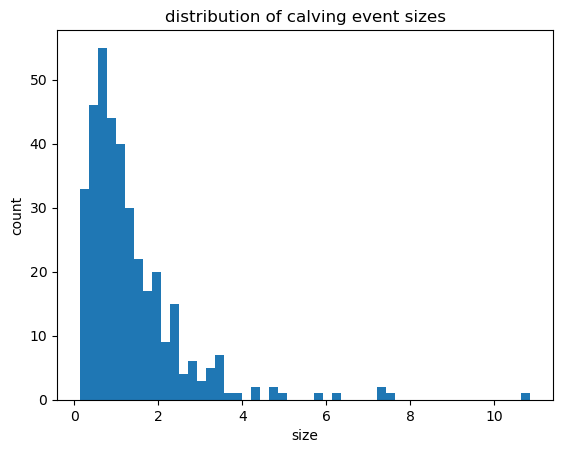

In [4]:
# so for glacial calving
#  if there is 1 event per day and we look at 365 days

L = 1 # event per day
T = 365 # days

# number of events 
N = np.random.poisson(L * T) #total number of calving events in a year

# event times - randomly distributed in the year
event_times = np.sort(np.random.uniform(0, T, N))

# glacier size
sizes = np.random.lognormal(mean=0, sigma=0.8, size = N)

# cumulative calved area
calved_area = np.cumsum(sizes)

plt.step(event_times, calved_area)
plt.xlabel("time")
plt.ylabel("total calved area")
plt.title("compound poisson of glacier calving")
plt.show()

plt.hist(sizes, bins=50)
plt.xlabel("size")
plt.ylabel("count")
plt.title("distribution of calving event sizes")
plt.show()

### 2. Poission statistics with Jakobshavn calving time series

We aim to characterize the statistical structure of the observed calving record by fitting a hierarchy of stochastic jump process models: 
1. Exponentially distributed event size and waiting times;

2. Gamma distributed event size and waiting times;

3. Time-varying sinusoidal processes; and 

4. A superposition of two distinct jump processes.


In [5]:
calving_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/Jakobshavn-Isbrae-CalvingStatistics/jakobshavn_calving_length_ts.csv"
df = pd.read_csv(calving_path, parse_dates=["Date"])

df = df.sort_values("Date").reset_index(drop=True)
df = df.dropna(subset=["calving_magnitude"]).reset_index(drop=True)
df.head()

,Date,vel_up_centreline,dLdt,calving,calving_magnitude,dt_days,dt_years,Centerline_Length
0,2016-10-12,11714.871094,-66053.938122,77768.809216,212.919396,6.0,0.016427,-1037.988013
1,2016-10-18,11177.864258,10971.578197,206.286060,0.564780,6.0,0.016427,-857.756749
2,2016-10-24,11086.111328,15959.660584,-4873.549256,-13.343051,6.0,0.016427,-595.585733
3,2016-10-30,11098.210938,11870.497179,-772.286242,-2.114404,6.0,0.016427,-400.587833
4,2016-11-05,10812.546875,9259.133052,1553.413823,4.253015,6.0,0.016427,-248.487084


In [6]:
# colors
dark_blue = "#1f3a5f"
light_blue = "#9ecae1"
middle_blue = "#6baed6"
teal = "#2a9d8f"

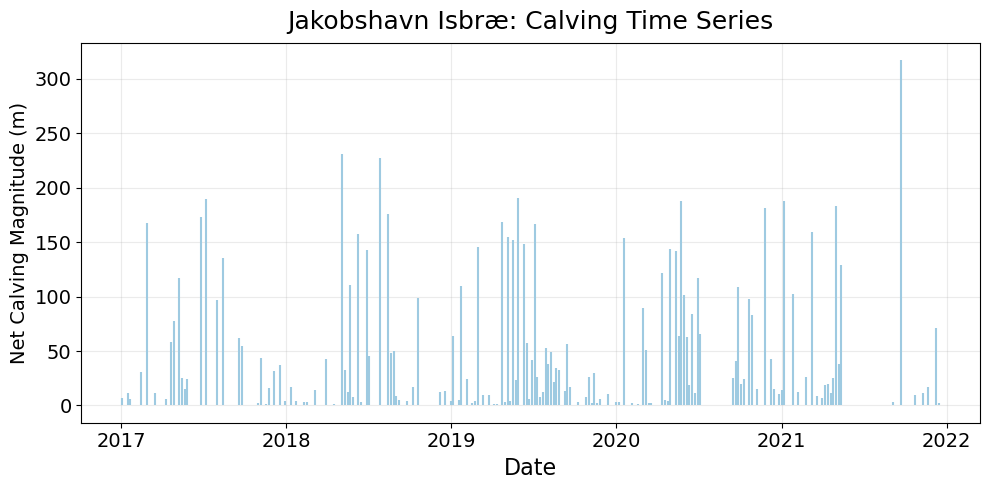

In [7]:
# cut to 2017
terminus_plot = df[df["Date"] >= "2017"].copy()

# mask negative values
terminus_plot["calving_positive"] = terminus_plot["calving_magnitude"].where(terminus_plot["calving_magnitude"] > 0)

plt.figure(figsize=(10, 5))
plt.vlines(terminus_plot["Date"], ymin = 0, ymax = terminus_plot["calving_positive"], color=light_blue)
plt.xlabel("Date", fontsize = 16)
plt.ylabel("Net Calving Magnitude (m)", fontsize = 14)
plt.title("Jakobshavn Isbræ: Calving Time Series", fontsize = 18, pad = 10)
plt.grid(True, alpha=0.25)
plt.xticks(size=14)
plt.yticks(size=14)
plt.tight_layout()
plt.show()

In [8]:
observed = terminus_plot[["Date", "calving_positive"]].copy()
observed = observed.dropna()
observed = observed[observed["calving_positive"] > 0]
observed["dt_days"] = observed["Date"].diff().dt.days

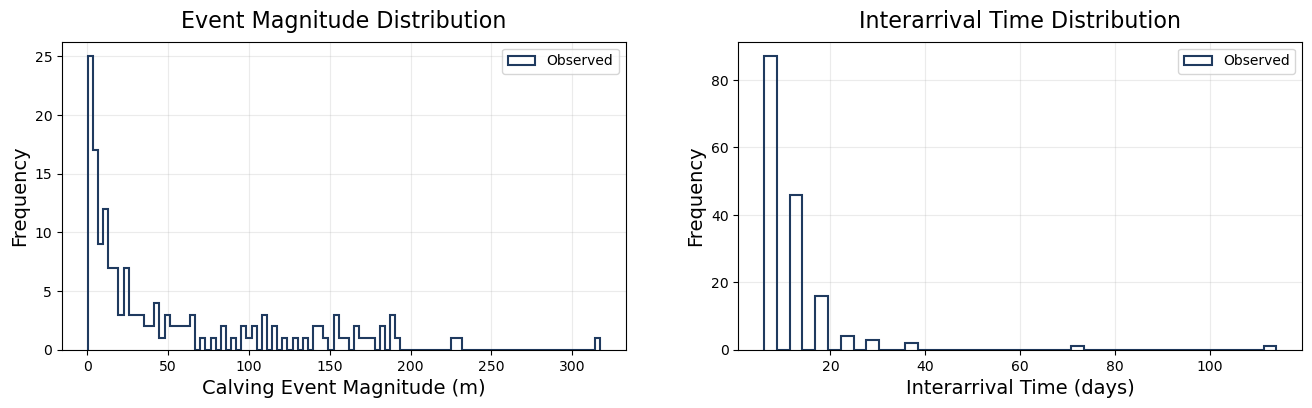

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

ax[0].hist(
    observed["calving_positive"],
    bins=100,
    histtype="step",
    linewidth=1.5,
    color = dark_blue,
    label = "Observed"
)

ax[0].set_xlabel("Calving Event Magnitude (m)", fontsize=14)
ax[0].set_ylabel("Frequency", fontsize=14)
ax[0].set_title("Event Magnitude Distribution", fontsize=16, pad = 10)
ax[0].grid(True, alpha = 0.25)
ax[0].legend()

ax[1].hist(
    observed["dt_days"].dropna(),
    bins=40,
    histtype="step",
    linewidth=1.5,
    color = dark_blue,
    label="Observed"
)

ax[1].set_xlabel("Interarrival Time (days)", fontsize=14)
ax[1].set_ylabel("Frequency", fontsize=14)
ax[1].set_title("Interarrival Time Distribution", fontsize=16, pad = 10)
ax[1].grid(True, alpha = 0.25)
ax[1].legend()

plt.show()

### 2a. Exponentially distributed event size and waiting times ###

In [14]:
def exp_calving(start_date, end_date, time_scale, size_scale, seed=None):
    """ exponential waiting times and exponential event sizes """
    rng = np.random.default_rng(seed)

    current_time = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    event_times = []
    event_sizes = []

    while current_time < end_date:
        # event_time generation
        wait_days = rng.exponential(scale=time_scale)
        current_time += pd.Timedelta(days=wait_days)

        if current_time < end_date:
            event_times.append(current_time)

            # event_size generation 
            size = rng.exponential(scale=size_scale)
            event_sizes.append(size)

    return pd.DataFrame({"Date": pd.to_datetime(event_times), "synthetic_calving": event_sizes})

In [ ]:
from scipy.stats import expon
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html

# expon.fit() returns two parameters: loc and scale.
# loc = location parameter - this shifts (L-R) the distribution 
# scale = scale parameter - equivalent to the mean of the data 

exp_event_sizes = observed["calving_positive"].dropna()
exp_event_sizes = exp_event_sizes[exp_event_sizes > 0]

exp_event_times = observed["dt_days"].dropna()
exp_event_times = exp_event_times[exp_event_times > 0]

size_loc, size_exp = expon.fit(exp_event_sizes)
time_loc, time_exp = expon.fit(exp_event_times)
# it says to do floc = 0 to make the location parameter 0 - can try that later

print("Event size location:", size_loc, "and event size scale:", size_exp)
print("Event time location;", time_loc, "and event time scale:", time_exp)


Event size location: 0.1456340134738973 and event size scale: 51.55770942125077
Event time location; 6.0 and event time scale: 5.2875


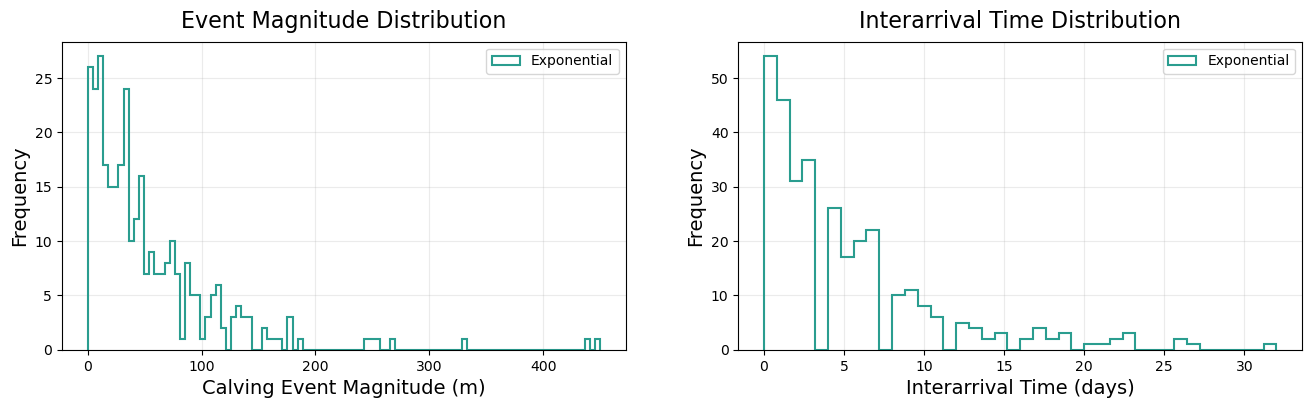

In [13]:
synthetic_exp = exp_calving(
    start_date=observed["Date"].min(),
    end_date=observed["Date"].max(),
    time_scale= time_exp,
    size_scale=size_exp,
    seed=36
)

fig, ax = plt.subplots(1, 2, figsize=(16, 4))

# exponential distribution of event sizes and waiting times
ax[0].hist(
    synthetic_exp["synthetic_calving"],
    bins=100,
    histtype="step",
    linewidth=1.5,
    color = teal,
    label = "Exponential"
)

ax[0].set_xlabel("Calving Event Magnitude (m)", fontsize=14)
ax[0].set_ylabel("Frequency", fontsize=14)
ax[0].set_title("Event Magnitude Distribution", fontsize=16, pad = 10)
ax[0].grid(True, alpha = 0.25)
ax[0].legend()

ax[1].hist(
    synthetic_exp["Date"].diff().dt.days.dropna(),
    bins=40,
    histtype="step",
    linewidth=1.5,
    color = teal,
    label="Exponential"
)

ax[1].set_xlabel("Interarrival Time (days)", fontsize=14)
ax[1].set_ylabel("Frequency", fontsize=14)
ax[1].set_title("Interarrival Time Distribution", fontsize=16, pad = 10)
ax[1].grid(True, alpha = 0.25)
ax[1].legend()

plt.show()



### 2b. Gamma distributed event size and waiting times ###

Gamma distributions have a shape parameter - determining the shape of the distribution, and a scale parameter (also known as a rate parameter) that can "shrink" or "compress" a distribution. 

In [15]:
def gamma_calving(start_date, end_date, time_shape, time_scale, size_shape, size_scale, seed=None):
    """gamma-distributed waiting times and gamma-distributed event sizes."""
    rng = np.random.default_rng(seed)

    current_time = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    event_times = []
    event_sizes = []

    while current_time < end_date:
        # event_time generation
        wait_days = rng.gamma(shape=time_shape, scale=time_scale)
        current_time += pd.Timedelta(days=wait_days)

        if current_time < end_date:
            event_times.append(current_time)

            # event_size generation
            size = rng.gamma(shape=size_shape, scale=size_scale)
            event_sizes.append(size)

    return pd.DataFrame({"Date": pd.to_datetime(event_times), "synthetic_calving": event_sizes})

In [16]:
from scipy.stats import gamma
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gamma.html

# gamma.fit() returns three parameters: shape, loc, and scale.
# shape = shape parameter - determines the shape of the distribution
# loc = location parameter - this shifts (L-R) the distribution
# scale = scale parameter - can "shrink" or "compress" a distribution

gamma_event_sizes = observed["calving_positive"].dropna()
gamma_event_sizes = gamma_event_sizes[gamma_event_sizes > 0]

gamma_event_times = observed["dt_days"].dropna()
gamma_event_times = gamma_event_times[gamma_event_times > 0]

size_shape, size_loc, size_scale = gamma.fit(gamma_event_sizes)
time_shape, time_loc, time_scale = gamma.fit(gamma_event_times)

print("Event size shape:", size_shape, "location:", size_loc, "and scale:", size_scale)
print("Event time shape:", time_shape, "location:", time_loc, "and scale:", time_scale)

Event size shape: 0.8234786180328055 location: 0.14563401347389726 and scale: 41.15258372748616
Event time shape: 0.22319787703366395 location: 5.999999999999999 and scale: 2.890255666517988


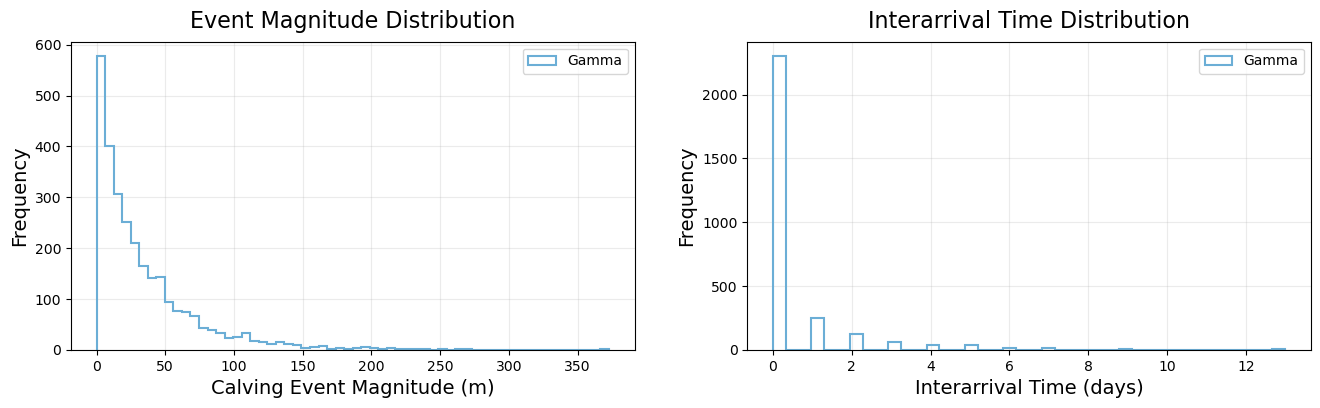

In [23]:
synthetic_gamma = gamma_calving(
    start_date=observed["Date"].min(),
    end_date=observed["Date"].max(),
    time_shape=time_shape,
    time_scale=time_scale,
    size_shape=size_shape,
    size_scale=size_scale,
    seed=42
)

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
# gamma distribution of event sizes and waiting times

ax[0].hist(
    synthetic_gamma["synthetic_calving"],
    bins=60,
    histtype="step",
    linewidth=1.5,
    color = middle_blue,
    label = "Gamma"
)

ax[0].set_xlabel("Calving Event Magnitude (m)", fontsize=14)
ax[0].set_ylabel("Frequency", fontsize=14)
ax[0].set_title("Event Magnitude Distribution", fontsize=16, pad = 10)
ax[0].grid(True, alpha = 0.25)
ax[0].legend()

ax[1].hist(
    synthetic_gamma["Date"].diff().dt.days.dropna(),
    bins=40,
    histtype="step",
    linewidth=1.5,
    color = middle_blue,
    label="Gamma"
)

ax[1].set_xlabel("Interarrival Time (days)", fontsize=14)
ax[1].set_ylabel("Frequency", fontsize=14)
ax[1].set_title("Interarrival Time Distribution", fontsize=16, pad = 10)
ax[1].grid(True, alpha = 0.25)
ax[1].legend()

plt.show()
